# Implicit maximum likelihood estimation — experiments

Companion notebook to the post **“Implicit maximum likelihood estimation (IMLE)”**.

The notebook is deliberately small-scale and explicit. It does not try to reproduce the paper's large image models. Instead, it isolates the mechanics that are otherwise hard to see:

1. the direction of nearest-neighbour matching;
2. the Monte Carlo IMLE objective;
3. the one-point likelihood intuition;
4. location fitting for a Gaussian and a Cauchy family;
5. mean fitting for a two-Gaussian mixture;
6. under-capacity and sparse-sample failure cases;
7. the difference between the literal theorem and the practical unweighted objective;
8. generation of all static figures and GIFs used in the post.

The original paper is Ke Li and Jitendra Malik, *Implicit Maximum Likelihood Estimation* (2018), arXiv:1809.09087.

## 0. What this notebook does — and does not claim

The paper proves an equivalence to maximum likelihood under explicit conditions. The most general theorem uses **weights depending on the unknown optimum**. The simple unweighted objective used in practice has the same optimizer in a special equal-density case; otherwise the paper motivates it as an upper-bound surrogate.

The toy fits below are therefore presented as **mechanism demonstrations**, not as a universal numerical proof that an arbitrary unweighted finite-sample IMLE objective equals MLE. To keep the matched examples identifiable and readable, the Gaussian and Cauchy experiments fit location with scale fixed, and the mixture experiment fits component means with weights and component scale fixed.

In [1]:

from __future__ import annotations

import copy
import json
import math
from dataclasses import dataclass
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image as DisplayImage, display
from PIL import Image

# Run from the post directory or directly from the artifacts directory.
ART = Path('.') if Path.cwd().name == 'artifacts' else Path('artifacts')
ART.mkdir(exist_ok=True)

BG, PANEL, LINE = '#0e1116', '#151a21', '#222a35'
FG, MUTED, ACCENT, ACCENT2 = '#d7dde6', '#8a94a3', '#4aa3ff', '#e0a458'
GREEN, RED, PURPLE = '#2a9d8f', '#d1495b', '#c792ea'

mpl.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': PANEL, 'savefig.facecolor': BG,
    'axes.edgecolor': LINE, 'axes.labelcolor': FG, 'text.color': FG,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'grid.color': LINE,
    'axes.grid': True, 'grid.linewidth': 0.6, 'grid.alpha': 0.35,
    'font.family': 'monospace', 'font.size': 10.5, 'figure.dpi': 110,
    'axes.titlesize': 12, 'legend.frameon': False,
})

def style(ax):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(LINE)
    ax.tick_params(colors=MUTED)
    return ax


## 1. The estimator

Let the data be $x_1,\dots,x_n$. Draw $m$ i.i.d. samples from the current implicit model,

$$\tilde x_1^\theta,\dots,\tilde x_m^\theta\sim P_\theta.$$

For each datum, measure the squared distance to the nearest sampled model point,

$$R_i^\theta=\min_{j\in[m]}\|\tilde x_j^\theta-x_i\|_2^2.$$

The practical IMLE objective is the expected one-sided nearest-neighbour cost

$$\mathcal L_{\rm IMLE}(\theta)=\mathbb E\left[\sum_{i=1}^n R_i^\theta\right].$$

The direction is important: **data points choose model samples**. A reverse objective, in which every model sample only needs to be close to some datum, can be small after dropping an entire data mode.

In [2]:

def normal_pdf(x, mu, sigma):
    sigma = max(float(sigma), 1e-8)
    x = np.asarray(x)
    return np.exp(-0.5 * ((x - mu) / sigma)**2) / (np.sqrt(2*np.pi) * sigma)

def cauchy_pdf(x, loc, scale):
    scale = max(float(scale), 1e-8)
    x = np.asarray(x)
    return 1.0 / (np.pi * scale * (1.0 + ((x - loc) / scale)**2))

def nearest_assignment(data, samples, loss='squared', delta=1.0):
    data = np.asarray(data, dtype=float)
    samples = np.asarray(samples, dtype=float)
    diff = samples[None, :] - data[:, None]
    if loss == 'squared':
        cost = diff**2
        grad = 2.0 * diff
    elif loss == 'huber':
        ad = np.abs(diff)
        cost = np.where(ad <= delta, 0.5*diff**2, delta*(ad - 0.5*delta))
        grad = np.where(ad <= delta, diff, delta*np.sign(diff))
    else:
        raise ValueError(loss)
    assignment = np.argmin(cost, axis=1)
    rows = np.arange(len(data))
    return assignment, float(cost[rows, assignment].mean()), grad[rows, assignment]


## 2. Direction of matching

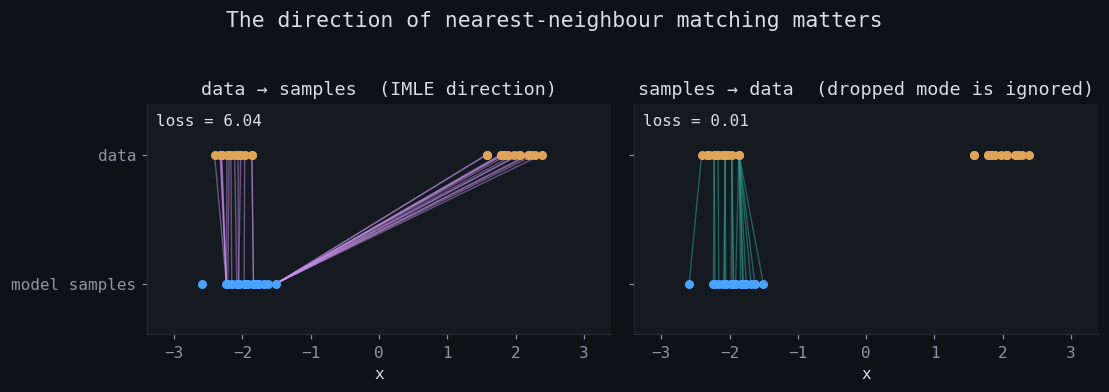

In [3]:

rng = np.random.default_rng(10)
data = np.r_[rng.normal(-2.1, 0.28, 14), rng.normal(2.1, 0.28, 14)]
model = rng.normal(-2.0, 0.32, 18)  # deliberately drops the right data mode

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.6), sharex=True, sharey=True)
for ax in axes:
    style(ax)
    ax.set_xlim(-3.4, 3.4); ax.set_ylim(0, 1)
    ax.set_yticks([0.22, 0.78]); ax.set_yticklabels(['model samples', 'data'])
    ax.scatter(data, np.full_like(data, 0.78), color=ACCENT2, s=24, zorder=3)
    ax.scatter(model, np.full_like(model, 0.22), color=ACCENT, s=24, zorder=3)
    ax.grid(False); ax.set_xlabel('x')

a, loss_forward, _ = nearest_assignment(data, model)
for i, j in enumerate(a):
    axes[0].plot([data[i], model[j]], [0.78, 0.22], color=PURPLE, lw=0.9, alpha=0.48)
axes[0].set_title('data → samples  (IMLE direction)')
axes[0].text(0.02, 0.96, f'loss = {loss_forward:.2f}', transform=axes[0].transAxes, va='top')

b, loss_reverse, _ = nearest_assignment(model, data)
for j, i in enumerate(b):
    axes[1].plot([data[i], model[j]], [0.78, 0.22], color=GREEN, lw=0.9, alpha=0.55)
axes[1].set_title('samples → data  (dropped mode is ignored)')
axes[1].text(0.02, 0.96, f'loss = {loss_reverse:.2f}', transform=axes[1].transAxes, va='top')

fig.suptitle('The direction of nearest-neighbour matching matters', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


## 3. One-point likelihood intuition

For a single datum $x$ and one random model sample $\tilde X$, define $R=\|\tilde X-x\|$. If the model density is high near $x$, the CDF $P(R\le r)$ grows quickly for small radii. Since a nonnegative random variable satisfies

$$E[R]=\int_0^\infty P(R>r)\,dr,$$

putting more probability mass near the datum lowers expected distance. The full multi-point theorem needs additional transformations, weights, and regularity assumptions; this is only the geometric core.

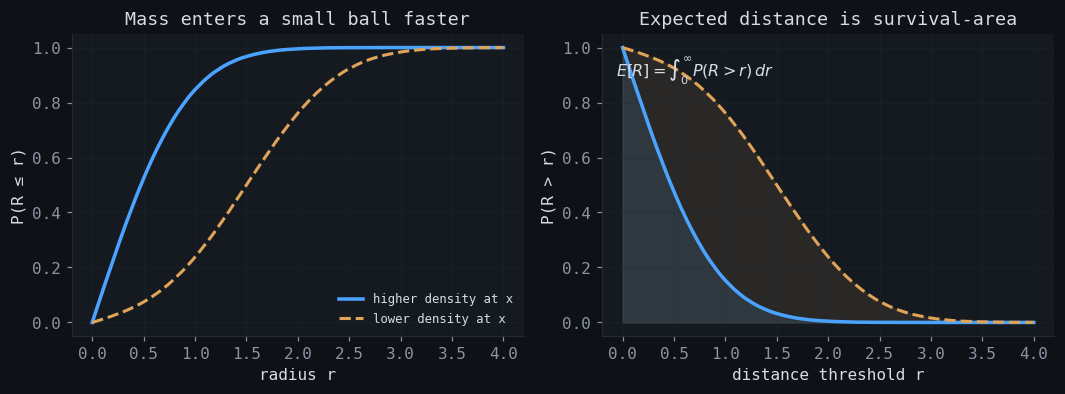

In [4]:

rng = np.random.default_rng(0)
r = np.linspace(0, 4.0, 300)
close = np.abs(rng.normal(0.0, 0.7, 200_000))
far = np.abs(rng.normal(1.5, 0.7, 200_000))
cdf_close = np.array([(close <= t).mean() for t in r])
cdf_far = np.array([(far <= t).mean() for t in r])

fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.7))
for ax in axes: style(ax)
axes[0].plot(r, cdf_close, color=ACCENT, lw=2.3, label='higher density at x')
axes[0].plot(r, cdf_far, color=ACCENT2, lw=2.0, ls='--', label='lower density at x')
axes[0].set(xlabel='radius r', ylabel='P(R ≤ r)', title='Mass enters a small ball faster')
axes[0].legend(fontsize=8)

axes[1].plot(r, 1-cdf_close, color=ACCENT, lw=2.3)
axes[1].plot(r, 1-cdf_far, color=ACCENT2, lw=2.0, ls='--')
axes[1].fill_between(r, 0, 1-cdf_close, color=ACCENT, alpha=0.13)
axes[1].fill_between(r, 0, 1-cdf_far, color=ACCENT2, alpha=0.10)
axes[1].set(xlabel='distance threshold r', ylabel='P(R > r)', title='Expected distance is survival-area')
axes[1].text(0.03, 0.93, r'$E[R]=\int_0^\infty P(R>r)\,dr$', transform=axes[1].transAxes, va='top')
fig.tight_layout()
plt.show()


## 4. What the theorem actually says

The paper introduces a function $\Psi(z)$ that connects local density $z$ to the smallest attainable expected nearest-sample distance at the origin. Under six assumptions—smoothness, translation closure, an ordering property, isolation of the MLE, differentiability of $\Psi$, and a non-orthogonality condition—the paper proves that a **weighted** expected nearest-distance objective has the same optimizer as maximum likelihood:

$$
\arg\min_\theta
\sum_i
\frac{E[R_i^\theta]}{\Psi'(p_{\theta^*}(x_i))p_{\theta^*}(x_i)}
=
\arg\max_\theta\sum_i\log p_\theta(x_i).
$$

If the optimal model assigns the same density to every training point, the weights are equal and may be removed. In general they depend on the unknown optimum. The practical algorithm therefore uses the unweighted objective and treats it as a tractable surrogate.

This is an important qualification: **“IMLE equals MLE” is a conditional theorem, not an unconditional identity for every model family, distance, finite sample count, and optimizer.**

## 5. A location-family objective cross-section

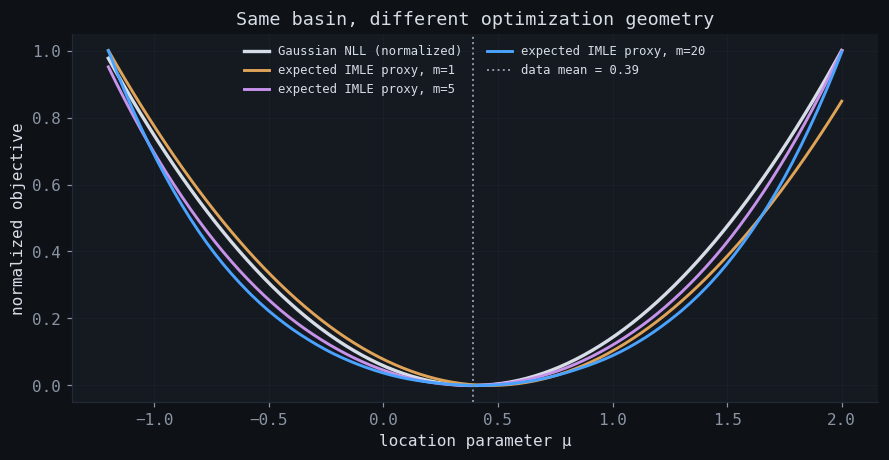

In [5]:

rng = np.random.default_rng(7)
data = 0.6 + rng.normal(size=60)
mu_grid = np.linspace(-1.2, 2.0, 180)
nll = np.array([0.5*np.mean((data-mu)**2) for mu in mu_grid])
nll = (nll - nll.min()) / (nll.max() - nll.min())

fig, ax = plt.subplots(figsize=(8.2, 4.3)); style(ax)
ax.plot(mu_grid, nll, color=FG, lw=2.2, label='Gaussian NLL (normalized)')
for m, color in [(1, ACCENT2), (5, PURPLE), (20, ACCENT)]:
    rr = np.random.default_rng(100 + m)
    value = np.zeros_like(mu_grid)
    for _ in range(240):
        z = rr.normal(size=m)
        samples = mu_grid[:, None] + z[None, :]
        diff = data[:, None, None] - samples[None, :, :]
        value += np.min(diff**2, axis=2).mean(axis=0)
    value /= 240
    value = (value - value.min()) / (value.max() - value.min())
    ax.plot(mu_grid, value, color=color, lw=1.9, label=f'expected IMLE proxy, m={m}')
ax.axvline(data.mean(), color=MUTED, ls=':', lw=1.3, label=f'data mean = {data.mean():.2f}')
ax.set(xlabel='location parameter μ', ylabel='normalized objective',
       title='Same basin, different optimization geometry')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()


## 6. Reusable toy trainers

In [6]:

@dataclass
class Snapshot:
    step: int
    params: dict
    data: np.ndarray
    samples: np.ndarray
    assignment: np.ndarray
    loss: float

def gaussian_location_history(seed=0, steps=30, n=120, m=12, batches=8, lr=0.4):
    rng = np.random.default_rng(seed)
    target_mu, sigma = 0.6, 1.0
    data = target_mu + sigma*rng.normal(size=n)
    mu = -1.2
    history = []
    for step in range(steps+1):
        dr = np.random.default_rng(20_000 + step)
        samples = mu + sigma*dr.normal(size=m)
        assignment, loss, _ = nearest_assignment(data, samples)
        history.append(Snapshot(step, {'mu':mu, 'sigma':sigma}, data.copy(), samples, assignment, loss))
        if step == steps: break
        g = 0.0
        for _ in range(batches):
            samples_b = mu + sigma*rng.normal(size=m)
            _, _, grad = nearest_assignment(data, samples_b)
            g += grad.mean()
        mu -= lr*g/batches
    return history

def gaussian_mixture_history(seed=1, steps=32, n=160, m=20, batches=8, lr=0.5):
    rng = np.random.default_rng(seed)
    sigma = 0.55
    comp = rng.integers(0, 2, size=n)
    data = np.where(comp == 0, -2.0, 2.0) + sigma*rng.normal(size=n)
    mu1, mu2 = -0.5, 0.5
    history = []
    for step in range(steps+1):
        dr = np.random.default_rng(30_000 + step)
        dc = np.arange(m) % 2; dr.shuffle(dc)
        samples = np.where(dc == 0, mu1, mu2) + sigma*dr.normal(size=m)
        assignment, loss, _ = nearest_assignment(data, samples)
        history.append(Snapshot(step, {'mu1':mu1, 'mu2':mu2, 'sigma':sigma}, data.copy(), samples, assignment, loss))
        if step == steps: break
        g1 = g2 = 0.0
        for _ in range(batches):
            sc = np.arange(m) % 2; rng.shuffle(sc)
            samples_b = np.where(sc == 0, mu1, mu2) + sigma*rng.normal(size=m)
            a, _, selected_grad = nearest_assignment(data, samples_b)
            grad_samples = np.zeros(m)
            for i, j in enumerate(a): grad_samples[j] += selected_grad[i]/n
            g1 += grad_samples[sc == 0].sum(); g2 += grad_samples[sc == 1].sum()
        mu1 -= lr*g1/batches; mu2 -= lr*g2/batches
        if mu1 > mu2: mu1, mu2 = mu2, mu1
    return history

def cauchy_location_history(seed=1, steps=38, n=120, m=12, batches=12, lr=0.15):
    rng = np.random.default_rng(seed)
    target_loc, scale = 0.4, 1.0
    u = np.clip(rng.random(n), 0.01, 0.99)
    data = target_loc + scale*np.tan(np.pi*(u-0.5))
    loc = 0.0
    history = []
    for step in range(steps+1):
        dr = np.random.default_rng(40_000 + step)
        ud = np.clip(dr.random(m), 0.01, 0.99)
        samples = loc + scale*np.tan(np.pi*(ud-0.5))
        assignment, loss, _ = nearest_assignment(data, samples)
        history.append(Snapshot(step, {'loc':loc, 'scale':scale}, data.copy(), samples, assignment, loss))
        if step == steps: break
        g = 0.0
        for _ in range(batches):
            ub = np.clip(rng.random(m), 0.01, 0.99)
            samples_b = loc + scale*np.tan(np.pi*(ub-0.5))
            _, _, selected_grad = nearest_assignment(data, samples_b)
            g += np.clip(selected_grad, -4, 4).mean()
        loc -= lr*g/batches
    return history


### Why the examples fix some parameters

With a finite sample set and an unweighted nearest-neighbour objective, scale can interact strongly with sample count: a broader model may cover a finite dataset with more widely spread samples. That behavior is itself worth studying, but it obscures the basic assignment mechanism. The first three experiments therefore fit only location-like parameters. The failure section later frees the Gaussian scale deliberately.

## 7. Matched Gaussian location

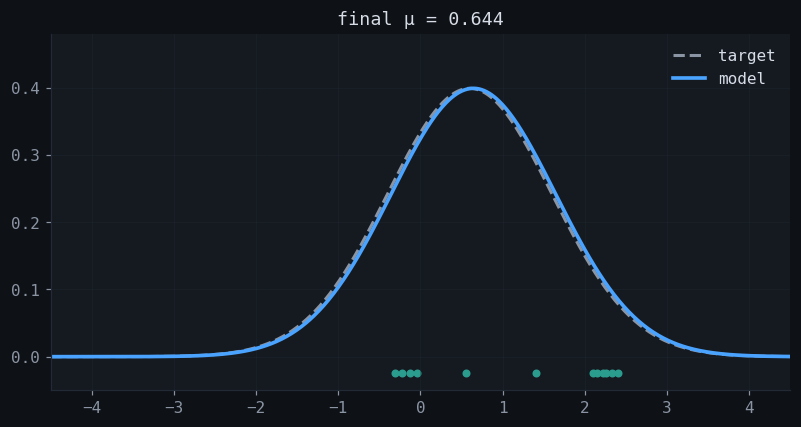

In [7]:

gaussian_hist = gaussian_location_history()
final = gaussian_hist[-1]
x = np.linspace(-4.5, 4.5, 600)
fig, ax = plt.subplots(figsize=(7.4, 4.0)); style(ax)
ax.plot(x, normal_pdf(x, 0.6, 1.0), color=MUTED, lw=2, ls='--', label='target')
ax.plot(x, normal_pdf(x, final.params['mu'], 1.0), color=ACCENT, lw=2.4, label='model')
ax.scatter(final.samples, np.full_like(final.samples, -0.025), color=GREEN, s=18)
ax.set(xlim=(-4.5,4.5), ylim=(-0.05,0.48), title=f"final μ = {final.params['mu']:.3f}")
ax.legend(); plt.tight_layout(); plt.show()


## 8. Matched two-Gaussian mixture

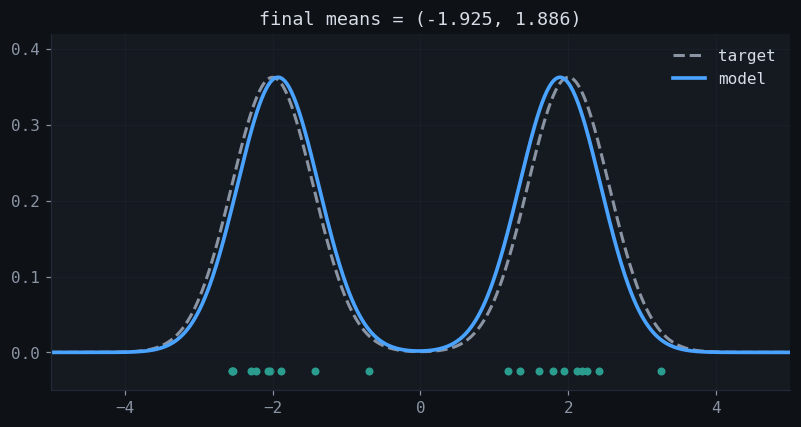

In [8]:

mixture_hist = gaussian_mixture_history()
final = mixture_hist[-1]
x = np.linspace(-5, 5, 600)
target = 0.5*normal_pdf(x,-2,0.55) + 0.5*normal_pdf(x,2,0.55)
model = 0.5*normal_pdf(x,final.params['mu1'],0.55) + 0.5*normal_pdf(x,final.params['mu2'],0.55)
fig, ax = plt.subplots(figsize=(7.4,4.0)); style(ax)
ax.plot(x,target,color=MUTED,lw=2,ls='--',label='target')
ax.plot(x,model,color=ACCENT,lw=2.4,label='model')
ax.scatter(final.samples,np.full_like(final.samples,-0.025),color=GREEN,s=18)
ax.set(xlim=(-5,5), ylim=(-0.05,0.42), title=f"final means = ({final.params['mu1']:.3f}, {final.params['mu2']:.3f})")
ax.legend(); plt.tight_layout(); plt.show()


## 9. Matched Cauchy location

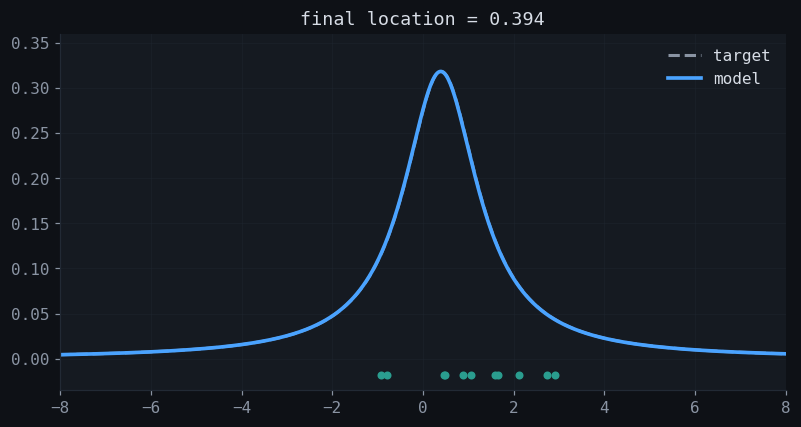

In [9]:

cauchy_hist = cauchy_location_history()
final = cauchy_hist[-1]
x = np.linspace(-8,8,700)
fig, ax = plt.subplots(figsize=(7.4,4.0)); style(ax)
ax.plot(x,cauchy_pdf(x,0.4,1.0),color=MUTED,lw=2,ls='--',label='target')
ax.plot(x,cauchy_pdf(x,final.params['loc'],1.0),color=ACCENT,lw=2.4,label='model')
shown = final.samples[(final.samples>-8)&(final.samples<8)]
ax.scatter(shown,np.full_like(shown,-0.018),color=GREEN,s=18)
ax.set(xlim=(-8,8), ylim=(-0.035,0.36), title=f"final location = {final.params['loc']:.3f}")
ax.legend(); plt.tight_layout(); plt.show()


## 10. Failure case: model under-capacity

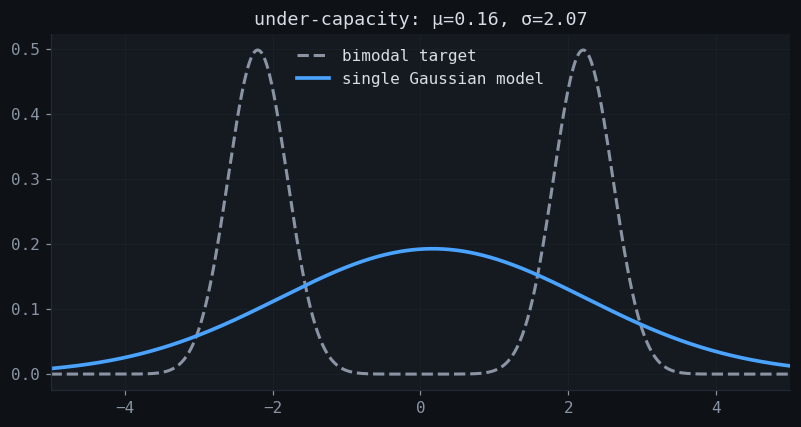

In [10]:

def underfit_history(seed=2, steps=34, n=160, m=12, batches=8, lr_mu=0.12, lr_logsigma=0.08):
    rng = np.random.default_rng(seed)
    comp = rng.integers(0,2,size=n)
    data = np.where(comp==0,-2.2,2.2) + 0.40*rng.normal(size=n)
    mu, log_sigma = 0.0, np.log(0.8)
    history = []
    for step in range(steps+1):
        dr = np.random.default_rng(50_000 + step)
        samples = mu + np.exp(log_sigma)*dr.normal(size=m)
        assignment, loss, _ = nearest_assignment(data, samples)
        history.append(Snapshot(step, {'mu':mu,'sigma':float(np.exp(log_sigma))}, data.copy(), samples, assignment, loss))
        if step == steps: break
        gmu = gls = 0.0
        for _ in range(batches):
            z = rng.normal(size=m)
            samples_b = mu + np.exp(log_sigma)*z
            a, _, selected_grad = nearest_assignment(data, samples_b)
            grad_samples = np.zeros(m)
            for i,j in enumerate(a): grad_samples[j] += selected_grad[i]/n
            gmu += grad_samples.sum()
            gls += np.sum(grad_samples*(samples_b-mu))
        mu -= lr_mu*gmu/batches
        log_sigma -= lr_logsigma*gls/batches
        log_sigma = float(np.clip(log_sigma, np.log(0.2), np.log(4.0)))
    return history

under_hist = underfit_history()
final = under_hist[-1]
x = np.linspace(-5,5,600)
target = 0.5*normal_pdf(x,-2.2,0.40) + 0.5*normal_pdf(x,2.2,0.40)
model = normal_pdf(x,final.params['mu'],final.params['sigma'])
fig, ax = plt.subplots(figsize=(7.4,4.0)); style(ax)
ax.plot(x,target,color=MUTED,lw=2,ls='--',label='bimodal target')
ax.plot(x,model,color=ACCENT,lw=2.4,label='single Gaussian model')
ax.set(title=f"under-capacity: μ={final.params['mu']:.2f}, σ={final.params['sigma']:.2f}", xlim=(-5,5))
ax.legend(); plt.tight_layout(); plt.show()


The objective cannot manufacture missing model capacity. A single Gaussian covers both modes by becoming broad. This is the same qualitative pressure usually associated with forward-KL / maximum-likelihood fitting under misspecification: recall is preserved at the expense of sharpness.

## 11. Failure case: too few model samples

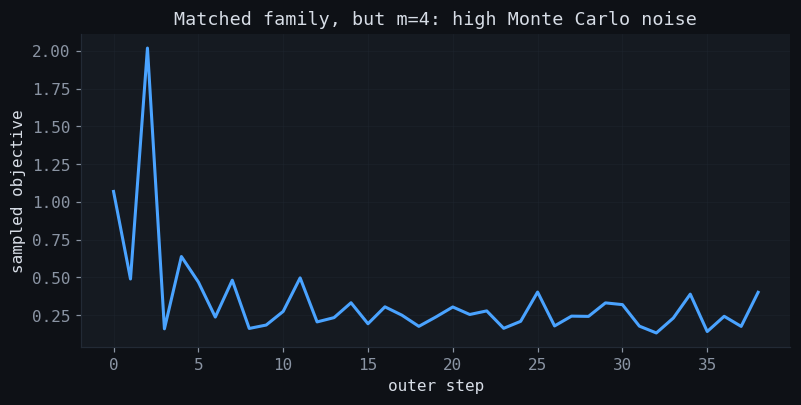

In [11]:

def few_samples_history(seed=3, steps=38, n=160, m=4, lr=0.3):
    rng = np.random.default_rng(seed)
    comp = rng.integers(0,2,size=n)
    sigma = 0.55
    data = np.where(comp==0,-2.0,2.0) + sigma*rng.normal(size=n)
    mu1, mu2 = -0.5, 0.5
    history = []
    for step in range(steps+1):
        sc = np.arange(m)%2; rng.shuffle(sc)
        samples = np.where(sc==0,mu1,mu2) + sigma*rng.normal(size=m)
        assignment, loss, selected_grad = nearest_assignment(data,samples)
        history.append(Snapshot(step,{'mu1':mu1,'mu2':mu2,'sigma':sigma},data.copy(),samples.copy(),assignment.copy(),loss))
        if step == steps: break
        grad_samples = np.zeros(m)
        for i,j in enumerate(assignment): grad_samples[j] += selected_grad[i]/n
        mu1 -= lr*grad_samples[sc==0].sum(); mu2 -= lr*grad_samples[sc==1].sum()
        if mu1>mu2: mu1,mu2=mu2,mu1
    return history

few_hist = few_samples_history()
losses = [s.loss for s in few_hist]
fig, ax = plt.subplots(figsize=(7.4,3.8)); style(ax)
ax.plot(losses,color=ACCENT,lw=2)
ax.set(xlabel='outer step', ylabel='sampled objective', title='Matched family, but m=4: high Monte Carlo noise')
plt.tight_layout(); plt.show()


## 12. Distance sensitivity and outliers

In [12]:

rng = np.random.default_rng(12)
clean = rng.normal(0,1,80)
contaminated = np.r_[clean, 9.0]
samples = rng.normal(-0.5,1,24)
_, sq_loss, sq_grad = nearest_assignment(contaminated,samples,loss='squared')
_, huber_loss, huber_grad = nearest_assignment(contaminated,samples,loss='huber',delta=1.0)
print({'squared_loss':sq_loss, 'mean_squared_gradient':float(sq_grad.mean()),
       'huber_loss':huber_loss, 'mean_huber_gradient':float(huber_grad.mean())})


{'squared_loss': 0.9682677887398581, 'mean_squared_gradient': -0.4309359906023288, 'huber_loss': 0.15046650198841144, 'mean_huber_gradient': -0.11475966419377626}


The original method uses Euclidean distance, and the paper notes that Euclidean distance in a learned embedding may be substituted. The choice is substantive: it defines which differences the generator is trained to reduce. Squared distance is especially sensitive to extreme unmatched points; perceptual embeddings or robust losses change the optimization problem, even when they are practically attractive.

## 13. Paper experiments in context

The original paper trained feed-forward implicit generators on MNIST, the Toronto Faces Dataset, and CIFAR-10. It reported:

- randomly selected samples rather than cherry-picked outputs;
- Gaussian Parzen-window likelihood estimates on MNIST and TFD;
- fixed-latent sample evolution during training;
- latent-space interpolations;
- generated samples beside their nearest neighbours in the training set.

Those experiments were intended to check several distinct questions: sample quality, diversity / recall, smoothness of the learned manifold, training stability, and simple memorization. The evaluation protocol is historically important but should not be treated as a modern definitive benchmark—especially the Parzen-window likelihood estimate in high dimensions.

## 14. Recreate the post artifacts

In [13]:

# Static assets and GIFs are already shipped next to this notebook.
# Set this to True after copying the complete artifact-generation functions
# from the post package if you want to regenerate every animation.
GENERATE_GIFS = False

shipped = sorted(p.name for p in ART.glob('imle-*'))
shipped


['imle-cauchy-location.gif',
 'imle-direction-of-matching.png',
 'imle-few-samples.gif',
 'imle-final-summary.png',
 'imle-gaussian-location.gif',
 'imle-gaussian-mixture.gif',
 'imle-objective-landscape.png',
 'imle-one-point-cdf.png',
 'imle-underfit.gif']

imle-gaussian-location.gif


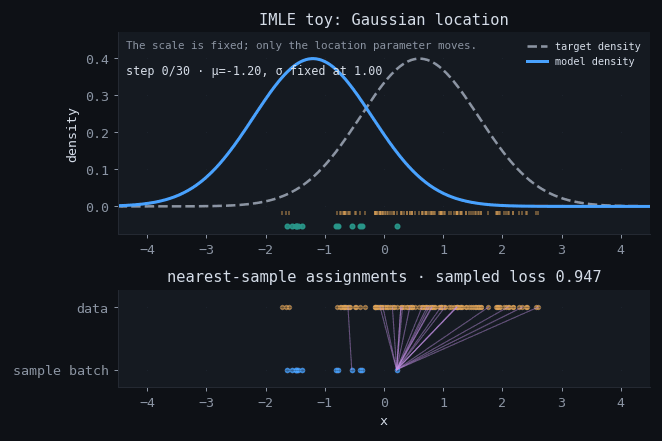

imle-gaussian-mixture.gif


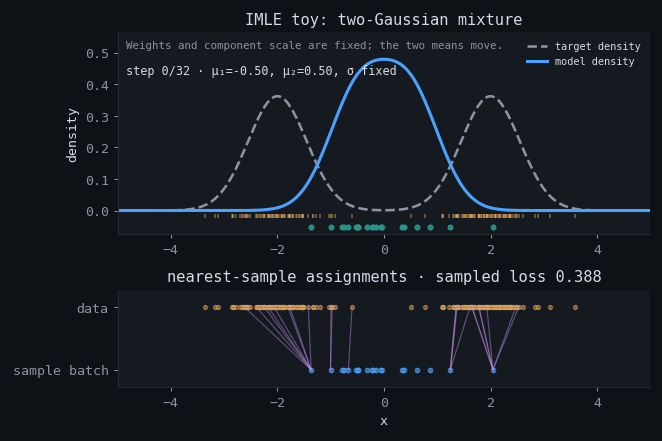

imle-cauchy-location.gif


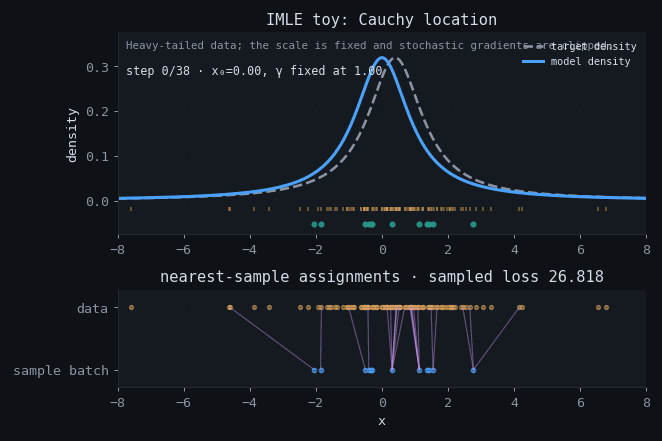

imle-underfit.gif


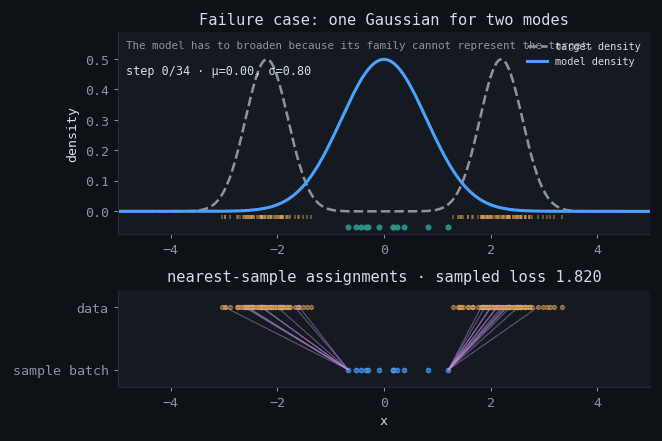

imle-few-samples.gif


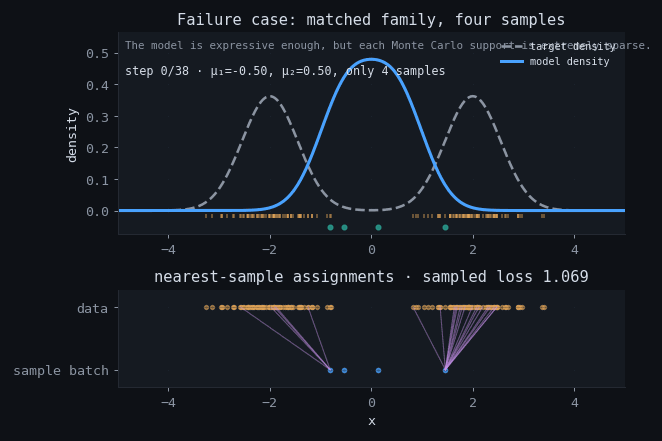

In [14]:

# Display the shipped animations in the notebook.
for name in [
    'imle-gaussian-location.gif',
    'imle-gaussian-mixture.gif',
    'imle-cauchy-location.gif',
    'imle-underfit.gif',
    'imle-few-samples.gif',
]:
    path = ART / name
    if path.exists():
        print(name)
        display(DisplayImage(filename=str(path)))


## 15. Conclusions

- IMLE trains an implicit sampler using one-sided nearest-neighbour matching from data to model samples.
- That direction makes dropped data modes expensive.
- The likelihood connection is real but conditional; the strongest theorem uses weights that depend on the optimum.
- The sampled objective has its own optimization geometry and Monte Carlo variance.
- Model capacity, sample count, and distance choice remain first-order design decisions.
- The small Gaussian, mixture, and Cauchy examples make the mechanism visible; the underfit and sparse-sample cases show where a clean objective still produces imperfect behavior.